# Section 2 — Intraday (H1) Feature Engineering for Daily Return Forecasting

**Goal.** Predict the *next day's* percentage return of EUR/USD using information
extracted from **H1 (1-hour) bars**. Rather than feeding 24 raw hourly prices per
day into the model — which would explode the feature count and inject a large
amount of microstructure **noise** — we compress each trading day into a handful
of hand-crafted statistics. This is deliberate **Feature Engineering**: trading
raw resolution for signal density to keep the model on the healthy side of the
**Bias–Variance Tradeoff**.

This notebook is a *self-contained exploratory study*. It does **not** touch the
production artifacts in `models/`; it mirrors the project's data-sourcing and
no-look-ahead conventions but trains a simple, transparent regularised linear
model so every modelling choice stays interpretable.

In [7]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression, RANSACRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (11, 4)

## Task 1 · Feature Engineering

### 1a. Load the raw H1 data

We reuse the project's live-data philosophy (`src/live_data.py`): try a local
**MetaTrader 5** terminal first (it stores deep H1 history), fall back to
**Yahoo Finance** `interval='1h'` (~730 calendar days), and finally to an on-disk
cache so re-runs are reproducible offline. The result is cached to
`../results/eurusd_h1.csv`. Paths are `../` because the notebook runs from
`notebooks/`.

In [8]:
H1_CACHE = os.path.join("..", "results", "eurusd_h1.csv")

def load_h1_data(symbol_mt5="EURUSD", symbol_yf="EURUSD=X", n_bars=60000, cache_path=H1_CACHE):
    """
    Load EUR/USD H1 (1-hour) OHLCV bars.

    Fallback chain mirrors src/live_data.py:
        MetaTrader5 terminal (TIMEFRAME_H1, deep history)
          -> Yahoo Finance interval='1h' (~730 calendar days)
          -> on-disk cache CSV
    Returns (dataframe, source_label).
    """
    # 1) MetaTrader 5 (Windows-only; deepest H1 history)
    try:
        import MetaTrader5 as mt5
        if mt5.initialize():
            rates = mt5.copy_rates_from_pos(symbol_mt5, mt5.TIMEFRAME_H1, 0, n_bars)
            mt5.shutdown()
            if rates is not None and len(rates):
                df = pd.DataFrame(rates)
                df["time"] = pd.to_datetime(df["time"], unit="s")
                df = df.set_index("time").sort_index()
                df = df[["open", "high", "low", "close", "tick_volume"]]
                os.makedirs(os.path.dirname(cache_path), exist_ok=True)
                df.to_csv(cache_path)
                return df, "MT5"
    except Exception:
        pass

    # 2) Yahoo Finance hourly (portable fallback, ~730 days)
    try:
        import yfinance as yf
        h = yf.Ticker(symbol_yf).history(period="730d", interval="1h")
        if h is not None and not h.empty:
            idx = h.index.tz_localize(None) if h.index.tz is not None else h.index
            vol = h["Volume"].astype(float).values if "Volume" in h.columns else 0.0
            df = pd.DataFrame({
                "open":  h["Open"].astype(float).values,
                "high":  h["High"].astype(float).values,
                "low":   h["Low"].astype(float).values,
                "close": h["Close"].astype(float).values,
                "tick_volume": vol,
            }, index=idx)
            df.index.name = "time"
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_csv(cache_path)
            return df, "yfinance"
    except Exception:
        pass

    # 3) On-disk cache (offline reproducibility)
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        return df, "cache"

    raise RuntimeError("No H1 source reachable and no cache present.")

h1, source = load_h1_data()
print(f"Loaded {len(h1):,} H1 bars from: {source}")
print(f"Range: {h1.index.min()}  ->  {h1.index.max()}")
h1.head()

Loaded 60,000 H1 bars from: MT5
Range: 2016-11-10 10:00:00  ->  2026-07-03 22:00:00


,open,high,low,close,tick_volume
time,,,,,
2016-11-10 10:00:00,1.09278,1.09283,1.08871,1.08938,7867
2016-11-10 11:00:00,1.08939,1.09067,1.08871,1.08996,6943
2016-11-10 12:00:00,1.08996,1.09201,1.08937,1.08979,7860
2016-11-10 13:00:00,1.08982,1.09104,1.08693,1.08913,8260
2016-11-10 14:00:00,1.08914,1.09073,1.08871,1.08979,9462


### 1b. Aggregate 24 hourly bars → one daily feature row

For each calendar day we collapse its (up to) 24 H1 bars into the four descriptive
features requested by the task, plus three weak extras so the L1 penalty later has
something meaningful to prune:

| Feature | Definition | Captures |
|---|---|---|
| **Intraday Volatility** | `std` of the day's H1 returns | how turbulent the session was |
| **Intraday Momentum** | last H1 close − first H1 open | the day's net directional drift |
| **Daily Range** | max H1 high − min H1 low | the total span the price travelled |
| **H1 Moving Average** | mean of the day's H1 closes | the day's average price level |

> **Why this *is* Feature Engineering, not mere resampling.** Each column is a
> domain-motivated summary statistic: volatility and range describe *risk*,
> momentum describes *direction*, the moving average anchors *level*. Four
> informative numbers per day generalise far better than 24×OHLC raw values,
> which would let the model memorise noise — the essence of **high variance /
> overfitting**.

*Caveat:* `H1 Moving Average` and `Daily Range` live on the absolute price scale
(~1.05) and are mildly non-stationary. We keep them because the task asks for
them, and let **standardisation + regularisation** damp their influence.

In [9]:
h1 = h1.copy()
h1["h1_return"] = h1["close"].pct_change()   # hour-over-hour simple return
h1["date"] = h1.index.normalize()            # calendar-day bucket

g = h1.groupby("date")   # groups the (up to) 24 hourly bars of each day

daily = pd.DataFrame({
    # --- the four features required by Task 1 ---
    "intraday_volatility": g["h1_return"].std(),                 # std of H1 returns
    "intraday_momentum":   g["close"].last() - g["open"].first(),# 24th close - 1st open
    "daily_range":         g["high"].max() - g["low"].min(),     # max price - min price
    "h1_moving_average":   g["close"].mean(),                    # mean of hourly closes
    # --- weak extras: give Lasso's L1 selection something to prune ---
    "h1_volume_mean":      g["tick_volume"].mean(),
    "last_hour_return":    g["h1_return"].last(),
    "hours_in_day":        g.size(),          # completeness sanity feature
})

# Keep reasonably complete FX weekdays. A full session is ~24 H1 bars; Fridays
# close early and holidays are short, so we require at least a half session.
daily = daily[daily["hours_in_day"] >= 12].copy()
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

print(f"{len(daily)} daily rows built from H1 aggregation")
daily.head()

2501 daily rows built from H1 aggregation


,intraday_volatility,intraday_momentum,daily_range,h1_moving_average,h1_volume_mean,last_hour_return,hours_in_day
date,,,,,,,
2016-11-10,0.000942,-0.00420,0.00636,1.088975,6791.357143,-0.000542,14
2016-11-11,0.001375,-0.00329,0.00929,1.087798,5707.782609,0.000526,23
2016-11-14,0.001807,-0.00942,0.01306,1.076436,5992.291667,0.000633,24
2016-11-15,0.001242,-0.00208,0.01025,1.074809,4889.625000,0.000177,24
2016-11-16,0.001466,-0.00245,0.00934,1.071179,4731.666667,0.000767,24


### 1c. Build the prediction target (no look-ahead)

The label is the **next** day's percentage return: `shift(-1)` of the daily
close-to-close return, expressed in **percent** to match the project convention.
Because row *D* is paired with the return realised on *D+1*, every feature is
known strictly *before* the target — there is **no look-ahead bias**. We drop the
boundary NaNs and never forward/backward-fill the target.

In [10]:
# Daily close = the last H1 close of each day, aligned to the filtered days.
daily_close = h1.groupby("date")["close"].last()
daily_close.index = pd.to_datetime(daily_close.index)
daily_close = daily_close.reindex(daily.index)

# Close-to-close daily return in PERCENT, then shift(-1) so row D holds D+1's return.
daily_ret_pct = daily_close.pct_change() * 100.0
daily["target_return"] = daily_ret_pct.shift(-1)

FEATURES = ["intraday_volatility", "intraday_momentum", "daily_range",
            "h1_moving_average", "h1_volume_mean", "last_hour_return"]

data = daily[FEATURES + ["target_return"]].dropna()   # drops boundary NaNs only
X, y = data[FEATURES], data["target_return"]

print(f"Modelling frame: {X.shape[0]} days x {X.shape[1]} features")
print(f"Target (next-day % return): mean={y.mean():+.4f}  std={y.std():.4f}")
X.describe().T[["mean", "std", "min", "max"]]

Modelling frame: 2500 days x 6 features
Target (next-day % return): mean=+0.0030  std=0.4510


,mean,std,min,max
intraday_volatility,0.000861,0.000393,0.000188,0.003934
intraday_momentum,0.000003,0.004978,-0.026970,0.023830
daily_range,0.007653,0.003637,0.001660,0.034150
h1_moving_average,1.123796,0.055394,0.961445,1.248407
h1_volume_mean,3943.499460,1863.318884,889.250000,17017.136364
last_hour_return,0.000039,0.000403,-0.004948,0.005168


## Task 3a · Train / Hold-out split

We lock away the most recent **20%** of days as an untouched **hold-out test
set**. For time-series data the split *must* be chronological: a random split
would let the model train on future days and validate on past ones — a classic
**look-ahead** leak that inflates scores and never survives live trading.

In [15]:
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  ({len(X_train)} days)")
print(f"Test : {X_test.index.min().date()} -> {X_test.index.max().date()}  ({len(X_test)} days)")

Train: 2016-11-10 -> 2024-07-26  (2000 days)
Test : 2024-07-29 -> 2026-07-02  (500 days)


## Task 2 · Regularised regression & the Bias–Variance Tradeoff

A plain `LinearRegression` on noisy financial features tends to **overfit**: it
chases the training residuals (mostly noise) and generalises poorly — **low bias,
high variance**. **Regularisation** adds a penalty on coefficient magnitudes that
deliberately trades a little **bias** for a large drop in **variance**:

- **Ridge (L2)** shrinks all coefficients smoothly toward zero — good when many
  features each contribute a little.
- **Lasso (L1)** can drive coefficients to *exactly* zero, performing automatic
  **feature selection** — good when some engineered features are redundant.
- **RANSAC** is a *robust* regressor: it fits on inlier samples and ignores
  outliers — useful because FX days have fat-tailed shocks.

The penalty strength `alpha` is the **bias–variance dial**: `alpha → 0` ≈ ordinary
least squares (high variance); large `alpha` ≈ near-constant model (high bias). We
choose it by cross-validation, never by peeking at the test set.

## Task 3b · Cross-Validation & Hyperparameter Tuning

We tune `alpha` with **`GridSearchCV`**, scoring by mean absolute error.

**A note on the CV splitter.** The textbook default is shuffled **K-Fold**, but
shuffling is *wrong* for time series: placing future rows in a training fold and
past rows in the validation fold leaks information. We therefore use scikit-learn's
**`TimeSeriesSplit`**, which only ever validates on data *after* its training
window — honest **Cross-Validation** that respects the arrow of time (and matches
this project's no-random-K-fold invariant). The `StandardScaler` lives *inside*
the pipeline, so it is re-fit on each training fold and never sees validation-fold
statistics.

In [16]:
tscv = TimeSeriesSplit(n_splits=5)          # expanding-window time-series CV
alphas = np.logspace(-4, 2, 25)             # 1e-4 ... 1e+2, the bias-variance grid

def tune(model, name):
    # Scaler inside the pipeline => re-fit per fold => no preprocessing leakage.
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    grid = GridSearchCV(pipe, {"model__alpha": alphas},
                        cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"{name:6s} | best alpha = {grid.best_params_['model__alpha']:.4g} "
          f"| CV MAE = {-grid.best_score_:.4f}%")
    return grid.best_estimator_, grid

ridge_best, ridge_grid = tune(Ridge(random_state=RANDOM_STATE), "Ridge")
lasso_best, lasso_grid = tune(Lasso(random_state=RANDOM_STATE, max_iter=50000), "Lasso")

Ridge  | best alpha = 100 | CV MAE = 0.3386%
Lasso  | best alpha = 0.05623 | CV MAE = 0.3371%


### Hold-out evaluation vs a no-skill baseline

The **only** honest score is on the untouched hold-out set. We compare Ridge,
Lasso and a robust **RANSAC** fit against a `DummyRegressor` that always predicts
the training-set mean return. `R² > 0` means a model genuinely beats "predict the
mean"; on near-efficient daily FX we expect everything to hover around the
baseline.

In [17]:
def evaluate(model, name):
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2   = r2_score(y_test, pred)
    print(f"{name:16s} | MAE {mae:.4f}% | RMSE {rmse:.4f}% | R2 {r2:+.4f}")
    return mae

# Robust regression on the same standardised features.
ransac = Pipeline([("scaler", StandardScaler()),
                   ("model", RANSACRegressor(estimator=LinearRegression(),
                                             random_state=RANDOM_STATE))]).fit(X_train, y_train)
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

print("Hold-out performance (lower MAE better; R2>0 beats the mean):")
evaluate(baseline, "Baseline(mean)")
evaluate(ridge_best, "Ridge")
evaluate(lasso_best, "Lasso")
evaluate(ransac,   "RANSAC")

Hold-out performance (lower MAE better; R2>0 beats the mean):
Baseline(mean)   | MAE 0.3383% | RMSE 0.4570% | R2 -0.0006
Ridge            | MAE 0.3384% | RMSE 0.4562% | R2 +0.0028
Lasso            | MAE 0.3383% | RMSE 0.4570% | R2 -0.0006
RANSAC           | MAE 0.4058% | RMSE 0.5414% | R2 -0.4044


0.40576737416720926

### What did Lasso keep? (L1 feature selection + the bias–variance dial)

Left: standardised Lasso coefficients — features driven to exactly `0` were
pruned by the L1 penalty. Right: the CV error as a function of `alpha`; the
minimum is the sweet spot of the **Bias–Variance Tradeoff** that `GridSearchCV`
selected.

Lasso coefficients (standardised features):
intraday_volatility    0.0
intraday_momentum      0.0
daily_range            0.0
h1_moving_average      0.0
h1_volume_mean         0.0
last_hour_return       0.0

L1 kept 0/6 features; the rest were shrunk to exactly 0.


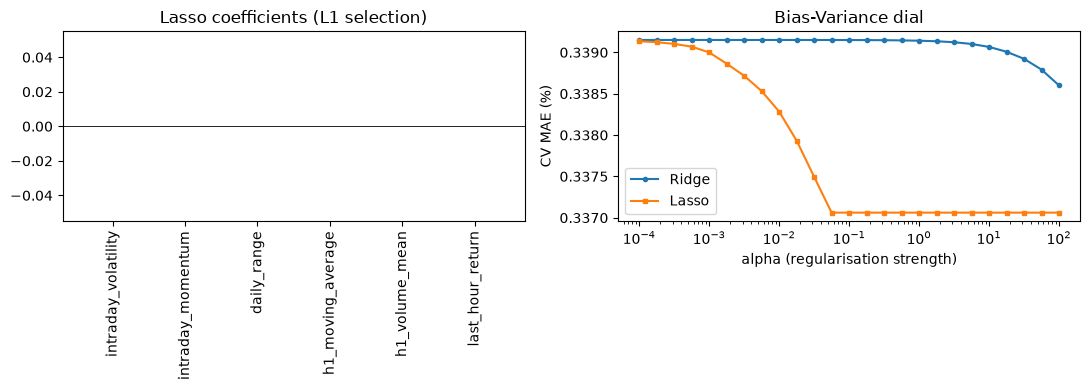

In [19]:
coef = pd.Series(lasso_best.named_steps["model"].coef_, index=FEATURES)
kept = int((coef != 0).sum())
print("Lasso coefficients (standardised features):")
print(coef.sort_values(key=abs, ascending=False).to_string())
print(f"\nL1 kept {kept}/{len(FEATURES)} features; the rest were shrunk to exactly 0.")

fig, ax = plt.subplots(1, 2)
ax[0].bar(coef.index, coef.values)
ax[0].axhline(0, color="k", lw=.6)
ax[0].set_title("Lasso coefficients (L1 selection)")
ax[0].tick_params(axis="x", rotation=90)

ax[1].plot(alphas, -ridge_grid.cv_results_["mean_test_score"], marker="o", ms=3, label="Ridge")
ax[1].plot(alphas, -lasso_grid.cv_results_["mean_test_score"], marker="s", ms=3, label="Lasso")
ax[1].set_xscale("log")
ax[1].set_xlabel("alpha (regularisation strength)")
ax[1].set_ylabel("CV MAE (%)")
ax[1].set_title("Bias-Variance dial")
ax[1].legend()
plt.tight_layout()
plt.show()

## Results & honest interpretation

Daily EUR/USD is **near-efficient**: tomorrow's return is dominated by
unforecastable news, so an honest model's `R²` on the hold-out set sits around
**0 (often slightly negative)** and its predictions **shrink toward the ~0% mean**
— exactly what Ridge/Lasso do under a well-chosen `alpha`. Beating the
predict-the-mean baseline by a wide margin here would signal **leakage**, not a
genuine edge. This mirrors the finding documented for the production models in
`ARCHITECTURE_DOCS.md` §4.2.1.

The value of this section is the **method**, not a magic signal:

1. **Feature Engineering** — 24 hourly bars distilled into 4 domain-motivated
   daily statistics (+3 weak extras), reducing variance at the source.
2. A **leak-free protocol** — chronological hold-out, `shift(-1)` target,
   scaler-inside-pipeline, and `TimeSeriesSplit` cross-validation.
3. **Regularisation** — Ridge/Lasso tuned via `GridSearchCV` to sit at the
   bottom of the bias–variance curve, with Lasso doubling as feature selection.